# PHÁT HIỆN TIN GIẢ - MẠNG RNN THƯỜNG
Dataset: Fake_News_Detection_Dataset.csv

Mục tiêu: Xây dựng mạng RNN thường (Simple RNN) để phân loại bài báo là tin thật hoặc tin giả.

- Đầu ra: 1 neuron (xác suất bài báo là tin giả)
- Loss: BCEWithLogitsLoss (Binary Cross Entropy)
- Activation: Sigmoid

## a. Tiền xử lý dữ liệu & Thiết lập dữ liệu

In [17]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import re
import string

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cpu


In [18]:
# Đọc dữ liệu
df = pd.read_csv('Fake_News_Detection_Dataset.csv')
print(f'Số mẫu: {len(df)}')
print(f'Cột: {df.columns.tolist()}')
print(f'\nPhân bố nhãn:\n{df["label"].value_counts().to_string()}')
df.head()

Số mẫu: 3340
Cột: ['text', 'label']

Phân bố nhãn:
label
0    1670
1    1670


,text,label
0,trump tell million american hurricane victim r...,0
1,new york cable provider altice acc network new...,0
2,japan dentsu get small fine overtime breach de...,1
3,little kid toxic stress solve priscilla chan c...,1
4,fantasy football kicker ranking week warn some...,0


In [19]:
# Kiểm tra dữ liệu null
print(f'Dữ liệu null:\n{df.isnull().sum().to_string()}')
df = df.dropna(subset=['text', 'label'])
print(f'Số mẫu sau khi xử lý null: {len(df)}')

Dữ liệu null:
text     0
label    0
Số mẫu sau khi xử lý null: 3340


### Tokenization & Padding

In [20]:
def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['text_clean'] = df['text'].apply(preprocess_text)
print('Mẫu đã xử lý:')
print(df['text_clean'].iloc[0][:200])

Mẫu đã xử lý:
trump tell million american hurricane victim responsible trump tell million american hurricane victim responsible reader think story fact add two cent news president unite state tell million american 


In [21]:
# Xây dựng từ điển
from collections import Counter #dem tu xuat hien bao lan

def build_vocab(texts, max_words=20000):
    word_counts = Counter() #tao bo dem luu tan suat tu 
    for text in texts:
        word_counts.update(text.split()) #tach cau thanh tung tu
    vocab = {'<PAD>': 0, '<UNK>': 1} #0 - chen them  1 - tu la
    for word, count in word_counts.most_common(max_words - 2): #lay cac tu pho bien danh so tu 2
        vocab[word] = len(vocab)
    return vocab

vocab = build_vocab(df['text_clean'], max_words=20000)
print(f'Kích thước từ điển: {len(vocab)}')

Kích thước từ điển: 20000


In [22]:
MAX_LEN = 200 #do dai 1 bai bao

def text_to_indices(text, vocab, max_len):
    tokens = text.split() #tach thanh danh sach tu
    indices = [vocab.get(t, vocab['<UNK>']) for t in tokens] # xet tung tu de ra chi so
    if len(indices) < max_len:
        indices += [vocab['<PAD>']] * (max_len - len(indices)) #ngan ->  them 0 
    else:
        indices = indices[:max_len] # dai -> cat ngan
    return indices

X = np.array([text_to_indices(t, vocab, MAX_LEN) for t in df['text_clean']])
y = df['label'].values.astype(np.float32)

print(f'Input shape: {X.shape}')
print(f'Label shape: {y.shape}')

Input shape: (3340, 200)
Label shape: (3340,)


### Chia dữ liệu Train / Validation / Test

In [23]:
# Chia theo thứ tự, không shuffle
train_size = int(0.7 * len(X))
val_size = int(0.15 * len(X))

X_train, y_train = X[:train_size], y[:train_size]
X_val, y_val = X[train_size:train_size+val_size], y[train_size:train_size+val_size]
X_test, y_test = X[train_size+val_size:], y[train_size+val_size:]

print(f'Train: {X_train.shape[0]} mẫu')
print(f'Val:   {X_val.shape[0]} mẫu')
print(f'Test:  {X_test.shape[0]} mẫu')

Train: 2338 mẫu
Val:   501 mẫu
Test:  501 mẫu


### Dataset & DataLoader

In [24]:
class FakeNewsDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.long) # embedding yeu cau dau vao la so nguyen -> long
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self): # so luong bai bao trong dataset
        return len(self.X)
    def __getitem__(self, idx): # lay bai bao / nhan o vi tri tuong ung 
        return self.X[idx], self.y[idx]

BATCH_SIZE = 32 #1 batch 32 bai bao

train_dataset = FakeNewsDataset(X_train, y_train)
val_dataset = FakeNewsDataset(X_val, y_val)
test_dataset = FakeNewsDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f'Train batches: {len(train_loader)}')
print(f'Val batches:   {len(val_loader)}')
print(f'Test batches:  {len(test_loader)}')

Train batches: 74
Val batches:   16
Test batches:  16


## b. Xây dựng kiến trúc RNN & Huấn luyện

In [25]:
class SimpleRNN(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_size, num_layers, num_classes=1, dropout=0.3):
        super(SimpleRNN, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.rnn = nn.RNN(
            input_size=embed_dim, #128
            hidden_size=hidden_size, #64
            num_layers=num_layers,  #2
            batch_first=True, #batch,sequence,feature
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, num_classes) # 64 chieu -> 1 logit -> dua qua sigmoid

    def forward(self, x):
        embedded = self.embedding(x)            # (batch, seq_len, embed_dim) (32,200) -> (32,200,128)
        output, hidden = self.rnn(embedded)     # output: (batch, seq_len, hidden_size) -> (32,200,64)
        last_output = output[:, -1, :]          # (batch, hidden_size) tat ca bao trong batch | timestep cuoi | toan bo 64 dac trung -> (32,64)
        out = self.dropout(last_output)
        out = self.fc(out)                      # (batch, 1)  (32,64) -> (32, 1)
        return out.squeeze(1)                   # (32,)

print('Mô hình SimpleRNN đã định nghĩa.')

Mô hình SimpleRNN đã định nghĩa.


In [ ]:
# Hyperparameters
VOCAB_SIZE = len(vocab)
EMBED_DIM = 64
HIDDEN_SIZE = 32
NUM_LAYERS = 2
NUM_CLASSES = 1
LEARNING_RATE = 0.001
NUM_EPOCHS = 25

model = SimpleRNN(VOCAB_SIZE, EMBED_DIM, HIDDEN_SIZE, NUM_LAYERS, NUM_CLASSES).to(device)
print(model)
total_params = sum(p.numel() for p in model.parameters())
print(f'Tổng tham số: {total_params:,}')

SimpleRNN(
  (embedding): Embedding(20000, 64, padding_idx=0)
  (rnn): RNN(64, 32, num_layers=2, batch_first=True, dropout=0.3)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)
Tổng tham số: 1,285,281


In [27]:
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

### Huấn luyện mô hình

In [28]:
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(NUM_EPOCHS):
    # --- Train ---
    model.train()
    running_loss = 0.0
    all_preds, all_labels = [], []
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * X_batch.size(0)
        preds = (torch.sigmoid(outputs) >= 0.5).float()
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y_batch.cpu().numpy())

    train_loss = running_loss / len(train_dataset)
    train_acc = accuracy_score(all_labels, all_preds)
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    # --- Validation ---
    model.eval()
    val_loss = 0.0
    val_preds, val_labels = [], []
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            val_loss += loss.item() * X_batch.size(0)
            preds = (torch.sigmoid(outputs) >= 0.5).float()
            val_preds.extend(preds.cpu().numpy())
            val_labels.extend(y_batch.cpu().numpy())

    val_loss = val_loss / len(val_dataset)
    val_acc = accuracy_score(val_labels, val_preds)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f'Epoch [{epoch+1}/{NUM_EPOCHS}]  '
              f'Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | '
              f'Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}')

print('\nHuấn luyện hoàn tất!')

Epoch [1/25]  Train Loss: 0.6861 | Train Acc: 0.5676 | Val Loss: 0.6729 | Val Acc: 0.5749
Epoch [5/25]  Train Loss: 0.5761 | Train Acc: 0.7327 | Val Loss: 0.6338 | Val Acc: 0.6507
Epoch [10/25]  Train Loss: 0.4178 | Train Acc: 0.8050 | Val Loss: 0.6148 | Val Acc: 0.7465
Epoch [15/25]  Train Loss: 0.3657 | Train Acc: 0.8033 | Val Loss: 0.6832 | Val Acc: 0.6906
Epoch [20/25]  Train Loss: 0.3205 | Train Acc: 0.8409 | Val Loss: 0.7120 | Val Acc: 0.6966
Epoch [25/25]  Train Loss: 0.3401 | Train Acc: 0.8246 | Val Loss: 0.7034 | Val Acc: 0.6806

Huấn luyện hoàn tất!


## c. Đánh giá, Dự đoán & Lời giải

### Vẽ biểu đồ Loss & Accuracy

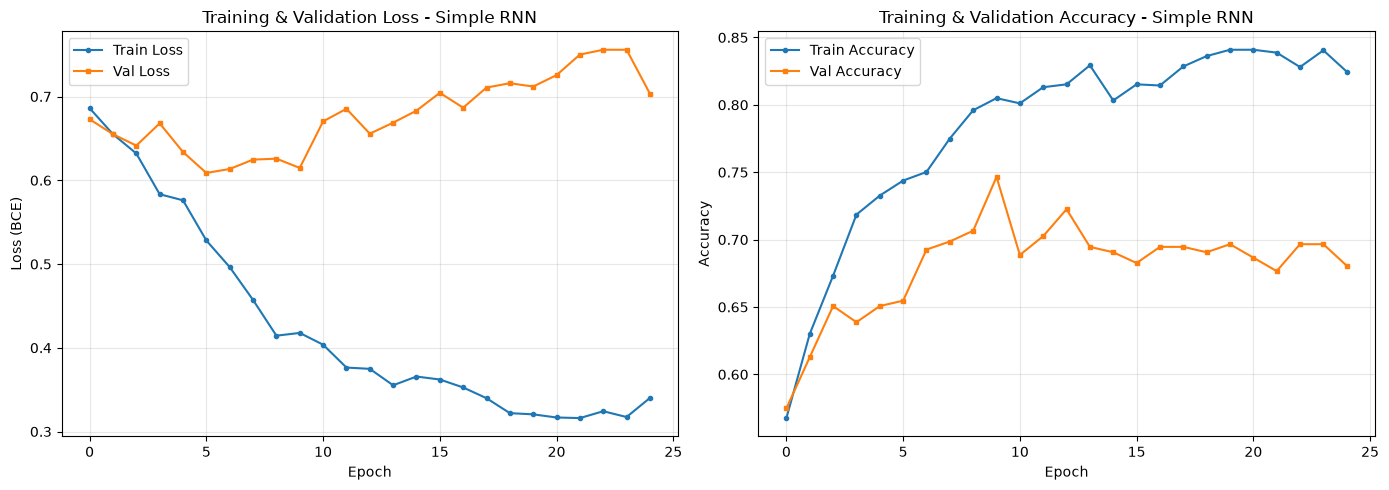

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(train_losses, label='Train Loss', marker='o', markersize=3)
axes[0].plot(val_losses, label='Val Loss', marker='s', markersize=3)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (BCE)')
axes[0].set_title('Training & Validation Loss - Simple RNN')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(train_accuracies, label='Train Accuracy', marker='o', markersize=3)
axes[1].plot(val_accuracies, label='Val Accuracy', marker='s', markersize=3)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Training & Validation Accuracy - Simple RNN')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Đánh giá trên Test Set

In [30]:
model.eval()
test_preds, test_labels = [], []
test_probs = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        outputs = model(X_batch)
        probs = torch.sigmoid(outputs)
        preds = (probs >= 0.5).float()
        test_preds.extend(preds.cpu().numpy())
        test_probs.extend(probs.cpu().numpy())
        test_labels.extend(y_batch.numpy())

test_preds = np.array(test_preds)
test_labels = np.array(test_labels)
test_probs = np.array(test_probs)

accuracy = accuracy_score(test_labels, test_preds)
precision = precision_score(test_labels, test_preds)
recall = recall_score(test_labels, test_preds)
f1 = f1_score(test_labels, test_preds)

print('=' * 50)
print('         KẾT QUẢ ĐÁNH GIÁ - Simple RNN')
print('=' * 50)
print(f'Accuracy:  {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall:    {recall:.4f}')
print(f'F1-Score:  {f1:.4f}')
print('=' * 50)
print('\nConfusion Matrix:')
print(confusion_matrix(test_labels, test_preds))
print('\nClassification Report:')
print(classification_report(test_labels, test_preds, target_names=['Tin thật (0)', 'Tin giả (1)']))

         KẾT QUẢ ĐÁNH GIÁ - Simple RNN
Accuracy:  0.6527
Precision: 0.8513
Recall:    0.5338
F1-Score:  0.6561

Confusion Matrix:
[[161  29]
 [145 166]]

Classification Report:
              precision    recall  f1-score   support

Tin thật (0)       0.53      0.85      0.65       190
 Tin giả (1)       0.85      0.53      0.66       311

    accuracy                           0.65       501
   macro avg       0.69      0.69      0.65       501
weighted avg       0.73      0.65      0.65       501



### Dự đoán mẫu thực tế

In [31]:
model.eval()

# Chọn 10 mẫu ngẫu nhiên từ test set
np.random.seed(42)
sample_indices = np.random.choice(len(X_test), 10, replace=False)

print('=' * 80)
print('DỰ ĐOÁN TIN GIẢ TRÊN MẪU THỰC TẾ - Simple RNN')
print('=' * 80)
print(f'{"Mẫu":<5} | {"Nhãn thực":<10} | {"Nhãn dự đoán":<12} | {"Xác suất":<10} | {"Kết quả":<8}')
print('-' * 80)

for i, idx in enumerate(sample_indices):
    x_input = torch.tensor([X_test[idx]], dtype=torch.long).to(device)
    with torch.no_grad():
        output = model(x_input)
        prob = torch.sigmoid(output).item()
        pred = 1 if prob >= 0.5 else 0
    actual = int(y_test[idx])
    label_map = {0: 'Thật', 1: 'Giả'}
    result = 'Đúng' if pred == actual else 'Sai'
    print(f'{i+1:<5} | {label_map[actual]:<10} | {label_map[pred]:<12} | {prob:.4f}     | {result}')

print('=' * 80)

DỰ ĐOÁN TIN GIẢ TRÊN MẪU THỰC TẾ - Simple RNN
Mẫu   | Nhãn thực  | Nhãn dự đoán | Xác suất   | Kết quả 
--------------------------------------------------------------------------------
1     | Giả        | Giả          | 0.9858     | Đúng
2     | Thật       | Thật         | 0.1855     | Đúng
3     | Giả        | Thật         | 0.1855     | Sai
4     | Thật       | Giả          | 0.9802     | Sai
5     | Thật       | Thật         | 0.4983     | Đúng
6     | Giả        | Giả          | 0.9652     | Đúng
7     | Giả        | Thật         | 0.0295     | Sai
8     | Thật       | Thật         | 0.0071     | Đúng
9     | Giả        | Giả          | 0.9761     | Đúng
10    | Giả        | Thật         | 0.1855     | Sai


### Ví dụ chi tiết 1 mẫu

In [32]:
# Lấy mẫu cuối cùng trong test set
sample_idx = len(X_test) - 1
x_input = torch.tensor([X_test[sample_idx]], dtype=torch.long).to(device)

with torch.no_grad():
    output = model(x_input)
    prob = torch.sigmoid(output).item()
    pred = 1 if prob >= 0.5 else 0

actual = int(y_test[sample_idx])
label_map = {0: 'Thật', 1: 'Giả'}

print('\n' + '=' * 60)
print('CHI TIẾT MẪU DỰ ĐOÁN - Simple RNN')
print('=' * 60)
print(f'Nhãn thực tế:   {label_map[actual]} ({actual})')
print(f'Nhãn dự đoán:   {label_map[pred]} ({pred})')
print(f'Xác suất tin giả: {prob:.4f}')
print(f'Chênh lệch:     {abs(prob - actual):.4f}')
print(f'Kết quả:        {"ĐÚNG" if pred == actual else "SAI"}')
print('=' * 60)


CHI TIẾT MẪU DỰ ĐOÁN - Simple RNN
Nhãn thực tế:   Giả (1)
Nhãn dự đoán:   Giả (1)
Xác suất tin giả: 0.9743
Chênh lệch:     0.0257
Kết quả:        ĐÚNG
